In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


In [34]:
df = pd.read_csv('../../../data/processed/combine_land_dataset_final_v1.csv')

In [35]:
df

,address_subdivision,address_locality,address_line_2,price_per_m2,land_area,price,longitude,latitude,near_Koh_Pich_in_km,Koh_Pich_nearest,...,f_trunk_link,f_unclassified,f_unused,geometry,population,h_id,mean_price_per_m2,max_price_per_m2,median_price_per_m2,min_price_per_m2
0,Phnom Penh,Doun Penh,Chakto Mukh,5442.340000,200.0,1088468.00,104.958218,11.558388,1,0,...,0,0,0,POINT (104.958218177304 11.55838750186468),8.0,8865846a39fffff,4968.196667,5442.340000,4842.500000,4619.75
1,Phnom Penh,Doun Penh,Srah Chak,4226.760000,248.0,1048236.48,104.920556,11.584438,4,0,...,0,0,0,POINT (104.9205562206213 11.58443847258666),29835.0,8865846aa5fffff,3792.457000,4414.290000,3961.015000,2608.12
2,Phnom Penh,Chamkar Mon,Boeng Trabaek,3899.110000,72.0,280735.92,104.920474,11.539412,2,0,...,0,0,0,POINT (104.9204743117011 11.53941192849337),18375.0,8865846ac1fffff,2985.163696,6250.000000,3178.947368,93.75
3,Phnom Penh,Tuol Kouk,Tuek L'ak Ti Bei,3813.960000,76.0,289860.96,104.886224,11.558990,6,0,...,0,0,0,POINT (104.8862240095462 11.55899002091164),16116.0,8865846a95fffff,3456.074000,3813.960000,3458.420000,3193.30
4,Phnom Penh,Doun Penh,Srah Chak,3580.150000,234.0,837755.10,104.909105,11.589344,5,0,...,0,0,0,POINT (104.9091054452488 11.58934447384246),36545.0,8865846aa7fffff,3389.313104,5103.990000,3617.020000,1300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6654,Phnom Penh,Saensokh,Phnom Penh Thmei,12.857143,1400.0,18000.00,104.920250,11.575610,3,0,...,0,0,0,POINT (104.92025 11.57561),16252.0,8865846aadfffff,2884.090269,10140.510000,2117.647059,1.00
6655,Phnom Penh,Chbar Ampov,Preaek Aeng,8.500000,400000.0,3400000.00,104.962474,11.522551,3,0,...,0,0,0,POINT (104.962474 11.522551),3342.0,8865846a51fffff,2075.961412,5000.000000,1900.000000,8.50
6656,Phnom Penh,Chraoy Chongvar,Chrouy Changvar,3.500000,10000.0,35000.00,104.925654,11.589674,4,0,...,1,0,0,POINT (104.925654 11.589674),11327.0,8865846819fffff,1951.915156,4888.888889,1843.750000,3.50
6657,Phnom Penh,Pur SenChey,Kamboul,1.000000,270000.0,270000.00,104.776086,11.531222,18,0,...,0,0,0,POINT (104.776086 11.5312221),1122.0,8865846e33fffff,756.053333,1147.410000,1119.750000,1.00


In [36]:
X = df.drop(columns=["price_per_m2", "address_locality", "address_subdivision", "price", "longitude", "latitude", "geometry"])
X = X.drop(columns=["mean_price_per_m2", "max_price_per_m2", "median_price_per_m2", "min_price_per_m2"])
y = df["price_per_m2"]

In [37]:
X

,address_line_2,land_area,near_Koh_Pich_in_km,Koh_Pich_nearest,Koh_Pich_1_2km,Koh_Pich_2_3km,Koh_Pich_3_5km,Koh_Pich_5_10km,near_Russian_Market_in_km,Russian_Market_nearest,...,f_service,f_steps,f_tertiary,f_track,f_trunk,f_trunk_link,f_unclassified,f_unused,population,h_id
0,Chakto Mukh,200.0,1,0,1,0,0,0,5,0,...,0,0,0,0,0,0,0,0,8.0,8865846a39fffff
1,Srah Chak,248.0,4,0,0,0,1,0,4,0,...,1,0,0,0,0,0,0,0,29835.0,8865846aa5fffff
2,Boeng Trabaek,72.0,2,0,0,1,0,0,0,1,...,1,0,1,0,0,0,0,0,18375.0,8865846ac1fffff
3,Tuek L'ak Ti Bei,76.0,6,0,0,0,0,1,3,0,...,0,0,0,0,0,0,0,0,16116.0,8865846a95fffff
4,Srah Chak,234.0,5,0,0,0,0,1,5,0,...,1,0,1,0,0,0,0,0,36545.0,8865846aa7fffff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6654,Phnom Penh Thmei,1400.0,3,0,0,0,1,0,3,0,...,1,0,1,0,0,0,0,0,16252.0,8865846aadfffff
6655,Preaek Aeng,400000.0,3,0,0,0,1,0,5,0,...,1,0,1,0,0,0,0,0,3342.0,8865846a51fffff
6656,Chrouy Changvar,10000.0,4,0,0,0,1,0,5,0,...,1,0,0,0,1,1,0,0,11327.0,8865846819fffff
6657,Kamboul,270000.0,18,0,0,0,0,0,15,0,...,0,0,0,0,0,0,0,0,1122.0,8865846e33fffff


In [38]:
# X = X.drop(columns=[col for col in X.columns if "5km" in col.lower() or "3km" in col.lower() or "in_km" in col.lower() or "2km" in col.lower()])

In [39]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['address_line_2', 'h_id']


In [40]:
X_original_categorical = X[categorical_cols].copy()

In [41]:
label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    
    # Create mapping dictionary
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"Encoding map for {col}: {mapping}")

# Save mappings to file (for future use)
import joblib
joblib.dump(label_encoders, '../../../data/processed/label_encoders_v2.pkl')


Encoding map for address_line_2: {'Bak Kaeng': 0, 'Boeng Kak Ti Muoy': 1, 'Boeng Kak Ti Pir': 2, 'Boeng Keng Kang Ti Bei': 3, 'Boeng Keng Kang Ti Muoy': 4, 'Boeng Keng Kang Ti Pir': 5, 'Boeng Proluet': 6, 'Boeng Reang': 7, 'Boeng Salang': 8, 'Boeng Thum': 9, 'Boeng Trabaek': 10, 'Boeng Tumpun': 11, 'Boeung Tumpun Mouy': 12, 'Boeung Tumpun Pir': 13, 'Chak Angrae Kraom': 14, 'Chak Angrae Leu': 15, 'Chakto Mukh': 16, 'Chaom Chau': 17, 'Chbar Ampov Ti Pir': 18, 'Cheung Aek': 19, 'Chey Chummeah': 20, 'Chey Chumneah': 21, 'Chhbar Ampov Ti Muoy': 22, 'Chhbar Ampov Ti Pir': 23, 'Chrang Chamreh Ti Muoy': 24, 'Chrang Chamreh Ti Pir': 25, 'Chrouy Changvar': 26, 'Dangkao': 27, 'Kakab': 28, 'Kakab Ti Mouy': 29, 'Kakab Ti Pir': 30, 'Kamboul': 31, 'Kantaok': 32, 'Kaoh Dach': 33, 'Kbal Kaoh': 34, 'Khmuonh': 35, 'Kilomaetr Lekh Prammuoy': 36, 'Kong Noy': 37, 'Kouk Khleang': 38, 'Kouk Roka': 39, 'Krang Pongro': 40, 'Krang Thnong': 41, 'Mittapheap': 42, 'Monourom': 43, 'Nirouth': 44, 'Olympic': 45, "Ou B

['../../../data/processed/label_encoders_v2.pkl']

In [42]:
selector = VarianceThreshold(threshold=0.01)
X_variance = selector.fit_transform(X_encoded)
selected_features_variance = X_encoded.columns[selector.get_support()]
print(f"Features after variance threshold: {list(selected_features_variance)}")
print(f"Removed features: {list(set(X_encoded.columns) - set(selected_features_variance))}")
X_filtered = pd.DataFrame(X_variance, columns=selected_features_variance)


Features after variance threshold: ['address_line_2', 'land_area', 'near_Koh_Pich_in_km', 'Koh_Pich_1_2km', 'Koh_Pich_2_3km', 'Koh_Pich_3_5km', 'Koh_Pich_5_10km', 'near_Russian_Market_in_km', 'Russian_Market_nearest', 'Russian_Market_1_2km', 'Russian_Market_2_3km', 'Russian_Market_3_5km', 'Russian_Market_5_10km', 'near_AEON_Mall_1_in_km', 'AEON_Mall_1_nearest', 'AEON_Mall_1_1_2km', 'AEON_Mall_1_2_3km', 'AEON_Mall_1_3_5km', 'AEON_Mall_1_5_10km', 'near_AEON_Mall_2_in_km', 'AEON_Mall_2_1_2km', 'AEON_Mall_2_2_3km', 'AEON_Mall_2_3_5km', 'AEON_Mall_2_5_10km', 'near_AEON_Mall_3_in_km', 'AEON_Mall_3_1_2km', 'AEON_Mall_3_2_3km', 'AEON_Mall_3_3_5km', 'AEON_Mall_3_5_10km', 'near_Bassac_Lane_in_km', 'Bassac_Lane_nearest', 'Bassac_Lane_1_2km', 'Bassac_Lane_2_3km', 'Bassac_Lane_3_5km', 'Bassac_Lane_5_10km', 'near_Koh_Norea_in_km', 'Koh_Norea_1_2km', 'Koh_Norea_2_3km', 'Koh_Norea_3_5km', 'Koh_Norea_5_10km', 'near_Camko_City_in_km', 'Camko_City_1_2km', 'Camko_City_2_3km', 'Camko_City_3_5km', 'Camko_Ci

In [43]:
corr_matrix = X_filtered.corr().abs()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
high_corr = (corr_matrix.mask(mask) >= 0.9).any()
features_to_remove = high_corr[high_corr].index.tolist()
X_uncorr = X_filtered.drop(columns=features_to_remove)
print(f"Removed correlated features: {features_to_remove}")
print(f"Features after correlation filter: {X_uncorr.columns.tolist()}")

Removed correlated features: ['near_Koh_Pich_in_km', 'near_Russian_Market_in_km', 'near_AEON_Mall_1_in_km', 'AEON_Mall_1_nearest', 'near_AEON_Mall_2_in_km', 'near_Bassac_Lane_in_km', 'Bassac_Lane_nearest', 'near_Koh_Norea_in_km', 'near_Camko_City_in_km', 'near_Olympic_Stadium_in_km', 'near_Phsar_Tmey_in_km', 'Phsar_Tmey_nearest', 'Phsar_Tmey_5_10km', 'near_Boeng_Keng_Kang_1_in_km', 'near_Wat_Phnom_in_km', 'Wat_Phnom_nearest', 'Wat_Phnom_5_10km', 'near_Chroy_Changvar_Bridge_in_km', 'near_Vattanac_Tower_in_km', 'near_Royal_Palace_in_km', 'near_Sisowath_Riverside_Park_in_km', 'Sisowath_Riverside_Park_nearest', 'Sisowath_Riverside_Park_1_2km', 'Sisowath_Riverside_Park_2_3km', 'Sisowath_Riverside_Park_5_10km', 'near_Phsar_Chas_in_km', 'Phsar_Chas_nearest', 'Phsar_kandal_3_5km', 'n_cafe_5km', 'n_cafe_in_1km_to_2km', 'n_cafe_in_2km_to_3km', 'n_cafe_in_3km_to_5km', 'n_gas_station_5km', 'n_gas_station_in_2km_to_3km', 'n_gas_station_in_3km_to_5km', 'n_hospital_5km', 'n_hospital_in_1km_to_2km', '

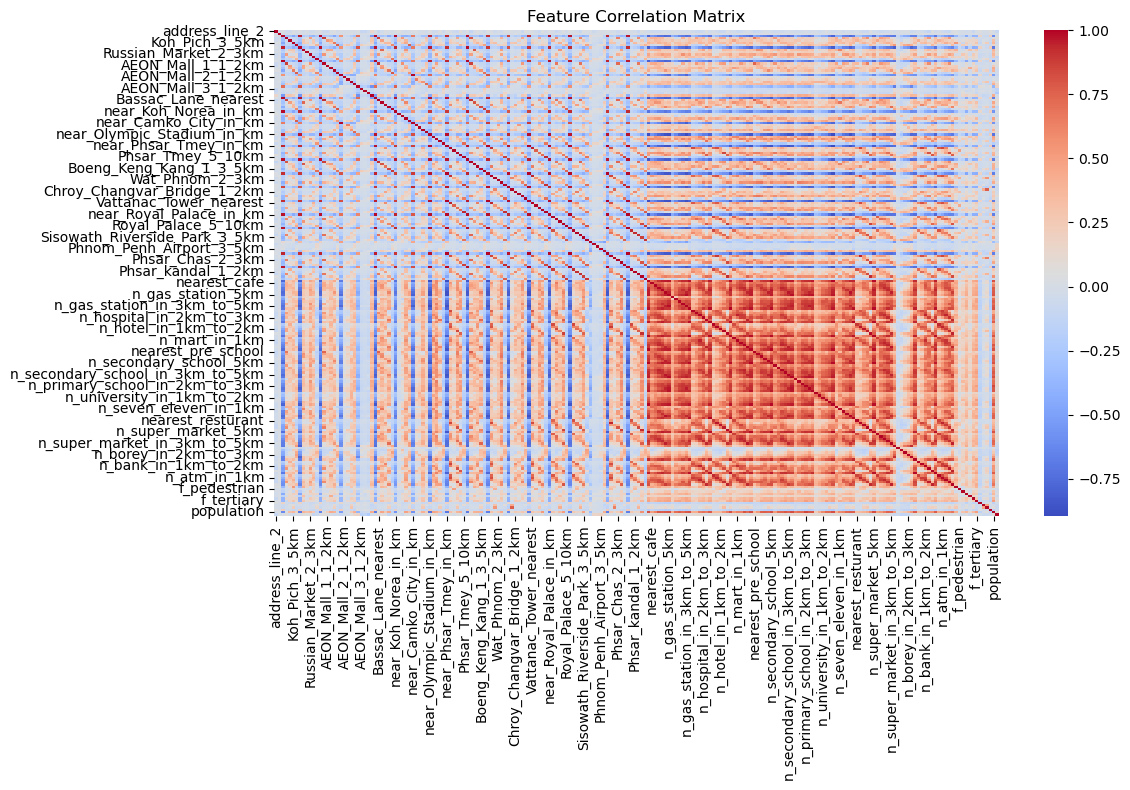

In [44]:
plt.figure(figsize=(12, 8))
sns.heatmap(X_filtered.corr(), cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [45]:
mi_scores = mutual_info_regression(X_uncorr, y)
mi_series = pd.Series(mi_scores, index=X_uncorr.columns).sort_values(ascending=False)
top_mi_features = mi_series.head(30).index.tolist()
print("Top features by Mutual Information:", top_mi_features)

Top features by Mutual Information: ['address_line_2', 'h_id', 'near_Phsar_kandal_in_km', 'population', 'n_university_in_3km_to_5km', 'n_atm_5km', 'n_atm_in_3km_to_5km', 'near_AEON_Mall_3_in_km', 'n_gas_station_in_1km_to_2km', 'n_borey_in_3km_to_5km', 'near_Phnom_Penh_Airport_in_km', 'n_pre_school_in_1km_to_2km', 'n_university_in_2km_to_3km', 'n_atm_in_2km_to_3km', 'n_seven_eleven_in_2km_to_3km', 'n_seven_eleven_in_1km_to_2km', 'n_atm_in_1km_to_2km', 'n_university_in_1km_to_2km', 'n_cafe_in_1km', 'n_primary_school_in_1km', 'n_atm_in_1km', 'n_pre_school_in_1km', 'n_secondary_school_in_1km', 'n_gas_station_in_1km', 'n_borey_in_2km_to_3km', 'n_borey_in_1km_to_2km', 'n_super_market_in_1km', 'n_university_in_1km', 'nearest_cafe', 'n_resturant_in_1km_to_2km']


In [46]:
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfe = RFE(estimator=rfr, n_features_to_select=20)
rfe.fit(X_uncorr[top_mi_features], y)
rfe_selected_features = X_uncorr[top_mi_features].columns[rfe.support_].tolist()
print("RFE-selected features:", rfe_selected_features)

RFE-selected features: ['address_line_2', 'h_id', 'near_Phsar_kandal_in_km', 'population', 'n_university_in_3km_to_5km', 'n_atm_5km', 'n_atm_in_3km_to_5km', 'near_AEON_Mall_3_in_km', 'n_gas_station_in_1km_to_2km', 'n_borey_in_3km_to_5km', 'near_Phnom_Penh_Airport_in_km', 'n_pre_school_in_1km_to_2km', 'n_university_in_2km_to_3km', 'n_seven_eleven_in_1km_to_2km', 'n_atm_in_1km_to_2km', 'n_cafe_in_1km', 'n_atm_in_1km', 'n_pre_school_in_1km', 'n_super_market_in_1km', 'n_resturant_in_1km_to_2km']


In [47]:
lasso = LassoCV(cv=5, random_state=42).fit(X_uncorr[top_mi_features], y)
lasso_selected_features = X_uncorr[top_mi_features].columns[lasso.coef_ != 0].tolist()
print("Lasso-selected features:", lasso_selected_features)

Lasso-selected features: ['population']


In [48]:
rfr.fit(X_uncorr[top_mi_features], y)
rf_importances = pd.Series(rfr.feature_importances_, index=top_mi_features)
top_rf_features = rf_importances.sort_values(ascending=False).head(20).index.tolist()
print("Top RandomForest features:", top_rf_features)

Top RandomForest features: ['n_atm_5km', 'address_line_2', 'n_atm_in_3km_to_5km', 'n_university_in_3km_to_5km', 'n_pre_school_in_1km', 'near_Phsar_kandal_in_km', 'n_atm_in_1km', 'n_super_market_in_1km', 'n_pre_school_in_1km_to_2km', 'population', 'near_AEON_Mall_3_in_km', 'near_Phnom_Penh_Airport_in_km', 'h_id', 'n_borey_in_3km_to_5km', 'n_gas_station_in_1km_to_2km', 'n_cafe_in_1km', 'n_resturant_in_1km_to_2km', 'n_university_in_2km_to_3km', 'n_atm_in_1km_to_2km', 'n_seven_eleven_in_1km_to_2km']


In [49]:
final_selected_features = list(set(rfe_selected_features) | set(lasso_selected_features) | set(top_rf_features))
print("Final selected features (union):", final_selected_features)

X_selected = X_uncorr[final_selected_features]

Final selected features (union): ['n_gas_station_in_1km_to_2km', 'n_borey_in_3km_to_5km', 'n_pre_school_in_1km', 'address_line_2', 'n_atm_in_1km_to_2km', 'n_super_market_in_1km', 'n_resturant_in_1km_to_2km', 'h_id', 'n_atm_in_3km_to_5km', 'population', 'near_Phnom_Penh_Airport_in_km', 'n_pre_school_in_1km_to_2km', 'n_cafe_in_1km', 'near_Phsar_kandal_in_km', 'n_seven_eleven_in_1km_to_2km', 'n_university_in_2km_to_3km', 'n_atm_5km', 'n_atm_in_1km', 'near_AEON_Mall_3_in_km', 'n_university_in_3km_to_5km']


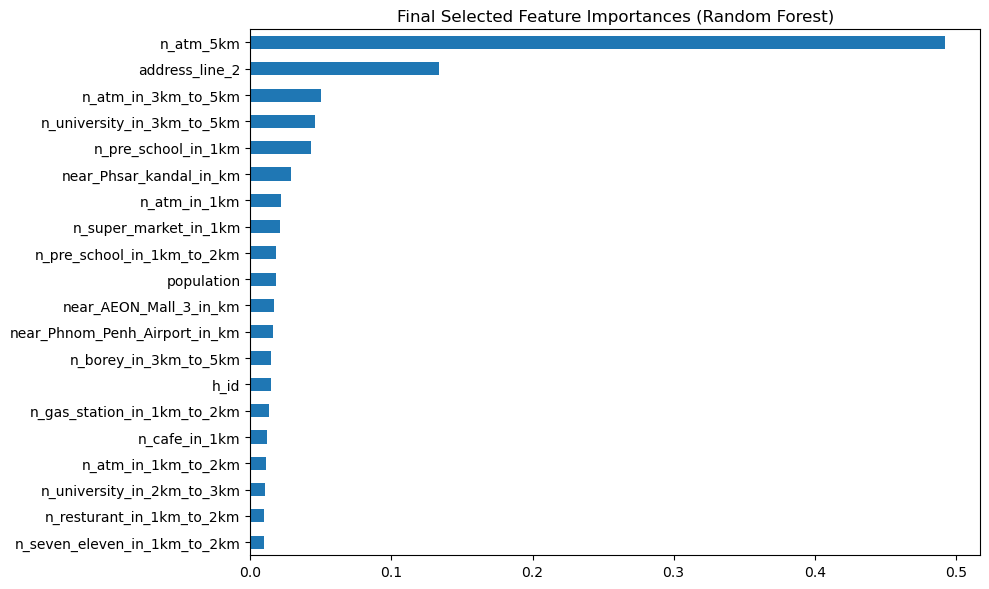

In [50]:
final_rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_rf_model.fit(X_selected, y)
importances = pd.Series(final_rf_model.feature_importances_, index=X_selected.columns)

plt.figure(figsize=(10, 6))
importances.sort_values(ascending=True).plot(kind='barh')
plt.title("Final Selected Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

In [51]:

print("Permutation Importance:")
print(importances.sort_values(ascending=False))

Permutation Importance:
n_atm_5km                        0.492478
address_line_2                   0.133714
n_atm_in_3km_to_5km              0.049833
n_university_in_3km_to_5km       0.045507
n_pre_school_in_1km              0.042732
near_Phsar_kandal_in_km          0.028725
n_atm_in_1km                     0.021455
n_super_market_in_1km            0.021248
n_pre_school_in_1km_to_2km       0.018374
population                       0.017898
near_AEON_Mall_3_in_km           0.016693
near_Phnom_Penh_Airport_in_km    0.015825
n_borey_in_3km_to_5km            0.014671
h_id                             0.014319
n_gas_station_in_1km_to_2km      0.013561
n_cafe_in_1km                    0.011481
n_atm_in_1km_to_2km              0.011338
n_university_in_2km_to_3km       0.010671
n_resturant_in_1km_to_2km        0.009938
n_seven_eleven_in_1km_to_2km     0.009541
dtype: float64


In [52]:
importances

n_gas_station_in_1km_to_2km      0.013561
n_borey_in_3km_to_5km            0.014671
n_pre_school_in_1km              0.042732
address_line_2                   0.133714
n_atm_in_1km_to_2km              0.011338
n_super_market_in_1km            0.021248
n_resturant_in_1km_to_2km        0.009938
h_id                             0.014319
n_atm_in_3km_to_5km              0.049833
population                       0.017898
near_Phnom_Penh_Airport_in_km    0.015825
n_pre_school_in_1km_to_2km       0.018374
n_cafe_in_1km                    0.011481
near_Phsar_kandal_in_km          0.028725
n_seven_eleven_in_1km_to_2km     0.009541
n_university_in_2km_to_3km       0.010671
n_atm_5km                        0.492478
n_atm_in_1km                     0.021455
near_AEON_Mall_3_in_km           0.016693
n_university_in_3km_to_5km       0.045507
dtype: float64

In [53]:
corr = df[['median_price_per_m2', 'price_per_m2']].corr().iloc[0, 1]
print(f"Correlation between population and price_per_m2: {corr:.4f}")


Correlation between population and price_per_m2: 0.7729


In [54]:
top_features_final = importances.head(20).index.tolist()
X_final = X[top_features_final]

In [55]:
final_df = pd.concat([X_final, y], axis=1)
final_df.to_csv('../../../data/preprocessed/selected_features_dataset.csv', index=False)

In [56]:
# Identify which categorical features are in the selected features
selected_categorical = [col for col in top_features_final if col in categorical_cols]
selected_numerical = [col for col in top_features_final if col not in categorical_cols]

print("Selected categorical features for one-hot encoding:", selected_categorical)
print("Selected numerical features:", selected_numerical)

# Initialize OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform only on selected categorical features
if selected_categorical:
    # Get the original categorical data for selected features
    X_cat_selected = X_original_categorical[selected_categorical]
    
    # One-hot encode
    X_ohe = ohe.fit_transform(X_cat_selected)
    
    # Get feature names
    ohe_feature_names = ohe.get_feature_names_out(selected_categorical)
    
    # Create DataFrame
    X_ohe_df = pd.DataFrame(X_ohe, columns=ohe_feature_names)
    
    # Save one-hot encoder
    joblib.dump(ohe, '../../../data/preprocessed/onehot_encoder_v2.pkl')
    print("OneHotEncoder saved")
else:
    X_ohe_df = pd.DataFrame()
    print("No categorical features selected for one-hot encoding")

# Combine with numerical features
X_num_selected = X[selected_numerical].reset_index(drop=True)

if not X_ohe_df.empty:
    X_onehot = pd.concat([X_num_selected, X_ohe_df], axis=1)
else:
    X_onehot = X_num_selected

Selected categorical features for one-hot encoding: ['address_line_2', 'h_id']
Selected numerical features: ['n_gas_station_in_1km_to_2km', 'n_borey_in_3km_to_5km', 'n_pre_school_in_1km', 'n_atm_in_1km_to_2km', 'n_super_market_in_1km', 'n_resturant_in_1km_to_2km', 'n_atm_in_3km_to_5km', 'population', 'near_Phnom_Penh_Airport_in_km', 'n_pre_school_in_1km_to_2km', 'n_cafe_in_1km', 'near_Phsar_kandal_in_km', 'n_seven_eleven_in_1km_to_2km', 'n_university_in_2km_to_3km', 'n_atm_5km', 'n_atm_in_1km', 'near_AEON_Mall_3_in_km', 'n_university_in_3km_to_5km']
OneHotEncoder saved


In [57]:
selected_categorical = [col for col in top_features_final if col in categorical_cols]
print("Selected categorical features for one-hot encoding:", selected_categorical)

Selected categorical features for one-hot encoding: ['address_line_2', 'h_id']


In [58]:
selected_label_encoders = {col: label_encoders[col] for col in selected_categorical if col in label_encoders}
import joblib
joblib.dump(selected_label_encoders, '../../../data/processed/label_encoders_selected_v2.pkl')

['../../../data/processed/label_encoders_selected_v2.pkl']

In [59]:
for col, le in selected_label_encoders.items():
    unique_values = list(le.classes_)
    print(f"{col}: {len(unique_values)} unique values")
    print(f"  Values: {unique_values}")

address_line_2: 110 unique values
  Values: ['Bak Kaeng', 'Boeng Kak Ti Muoy', 'Boeng Kak Ti Pir', 'Boeng Keng Kang Ti Bei', 'Boeng Keng Kang Ti Muoy', 'Boeng Keng Kang Ti Pir', 'Boeng Proluet', 'Boeng Reang', 'Boeng Salang', 'Boeng Thum', 'Boeng Trabaek', 'Boeng Tumpun', 'Boeung Tumpun Mouy', 'Boeung Tumpun Pir', 'Chak Angrae Kraom', 'Chak Angrae Leu', 'Chakto Mukh', 'Chaom Chau', 'Chbar Ampov Ti Pir', 'Cheung Aek', 'Chey Chummeah', 'Chey Chumneah', 'Chhbar Ampov Ti Muoy', 'Chhbar Ampov Ti Pir', 'Chrang Chamreh Ti Muoy', 'Chrang Chamreh Ti Pir', 'Chrouy Changvar', 'Dangkao', 'Kakab', 'Kakab Ti Mouy', 'Kakab Ti Pir', 'Kamboul', 'Kantaok', 'Kaoh Dach', 'Kbal Kaoh', 'Khmuonh', 'Kilomaetr Lekh Prammuoy', 'Kong Noy', 'Kouk Khleang', 'Kouk Roka', 'Krang Pongro', 'Krang Thnong', 'Mittapheap', 'Monourom', 'Nirouth', 'Olympic', "Ou Baek K'am", 'Ou Ruessei Ti Bei', 'Ou Ruessei Ti Muoy', 'Ou Ruessei Ti Pir', 'Ovlaok', 'Phleung Chheh Roteh', 'Phnom Penh Thmei', 'Phsar Chas', 'Phsar Daeum Kor', 'P

In [60]:
# Create final one-hot encoded dataset
final_df_onehot = pd.concat([X_onehot, y.reset_index(drop=True)], axis=1)
final_df_onehot.to_csv('../../../data/preprocessed/selected_features_onehot_encoded.csv', index=False)

In [61]:
# Use label-encoded features only for selected categorical columns
X_label_encoded_final = X[selected_numerical].copy()  # Start with selected numerical features

for col in selected_categorical:
    le = selected_label_encoders[col]
    X_label_encoded_final[col] = le.transform(X[col])

# Reorder to match original top_features_final order
X_label_encoded_final = X_label_encoded_final.reindex(columns=top_features_final)

# Combine with target
final_df_label = pd.concat([X_label_encoded_final, y.reset_index(drop=True)], axis=1)

# Save to CSV
final_df_label.to_csv('../../../data/preprocessed/selected_features_label_encoded.csv', index=False)
print("Label Encoded dataset saved.")

Label Encoded dataset saved.
